# Holistic Data Preparer
### Final Project — Customer Credit Risk Dataset
Duration: 8 Days (1 hour per day)


## Setup — importing all the libraries I need upfront

In [67]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (
    OrdinalEncoder, LabelEncoder,
    StandardScaler, MinMaxScaler,
    MaxAbsScaler, RobustScaler,
    Normalizer, FunctionTransformer, PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

print("Done Importing")


Done Importing


---
## Part A — Conceptual Foundation

### 1. Short Notes

**What is Data Analysis?**

Data analysis basically means taking raw data and turning it into something useful. You go through steps like collecting the data, cleaning it up (fixing missing values, duplicates etc.), exploring it to find patterns, and then drawing conclusions from it.

In simple terms the pipeline looks like this:

| Step | What happens |
|------|-------------|
| Collection | get data from wherever — CSV, API, DB |
| Cleaning | fix nulls, wrong types, duplicates |
| EDA | understand what the data looks like |
| Visualization | make charts to communicate findings |
| Conclusion | turn patterns into useful insights |

---

**How to plan a Data Science project**

Before jumping into code you need a clear plan. Here is what I follow:

| # | Phase | Description |
|---|-------|-------------|
| 1 | Problem Definition | what exactly are we trying to predict or solve |
| 2 | Data Collection | gather from CSVs, APIs, databases |
| 3 | Data Cleaning | handle nulls, fix types, remove garbage |
| 4 | EDA | explore distributions, correlations, outliers |
| 5 | Feature Engineering | create useful features, encode, scale |
| 6 | Modeling | pick and train an ML model |
| 7 | Evaluation | check accuracy, F1, AUC etc. |
| 8 | Deployment | serve the model somewhere |
| 9 | Monitoring | make sure it keeps performing well |

---

**How to frame this as an ML problem**

This dataset is about predicting whether a customer will default on a loan. That makes it a binary classification problem.

| Element | Detail |
|---------|--------|
| Problem type | Binary Classification |
| Target | default_flag — 0 means no default, 1 means default |
| Features | age, income, credit score, loan amount, employment type etc. |
| Metric | F1-score and ROC-AUC are better than accuracy here because the data is imbalanced |
| Challenge | there will be way fewer defaulters than non-defaulters |
| Fix | use SMOTE or set class_weight=balanced in the model |

---

### 2. Tensors — explanation with NumPy examples

A tensor is just a fancy name for a multi-dimensional array. Scalars, vectors and matrices are all special cases of tensors.

| Name | Dims | Example |
|------|------|---------|
| 0D / Scalar | 0 | just a number like 5 |
| 1D / Vector | 1 | [1, 2, 3, 4] |
| 2D / Matrix | 2 | a table with rows and columns |
| 3D Tensor | 3 | a stack of matrices, like an RGB image |
| nD Tensor | n | batches of data, video frames etc. |

In ML every input dataset is a 2D tensor of shape (samples, features).


In [68]:
# Demonstrating different dimensions of NumPy arrays
# 0D scalar
s = np.array(42)
print("scalar:", s, "| shape:", s.shape, "| dims:", s.ndim)

# 1D vector
v = np.array([10, 20, 30, 40, 50])
print("vector:", v, "| shape:", v.shape)

# 2D matrix
m = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print("matrix shape:", m.shape, "| dims:", m.ndim)
print(m)

# 3D tensor
t = np.zeros((3, 4, 4))
print("3D tensor shape:", t.shape, "| dims:", t.ndim, "| total elements:", t.size)


scalar: 42 | shape: () | dims: 0
vector: [10 20 30 40 50] | shape: (5,)
matrix shape: (3, 3) | dims: 2
[[1 2 3]
 [4 5 6]
 [7 8 9]]
3D tensor shape: (3, 4, 4) | dims: 3 | total elements: 48


In [69]:
# tensor indexing
# tensor properties
arr = np.array([[1.5, 2.5], [3.5, 4.5]])
print("shape    :", arr.shape)
print("size     :", arr.size)
print("ndim     :", arr.ndim)
print("dtype    :", arr.dtype)

# basic operations
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("add      :", a + b)
print("multiply :", a * b)
print("dot      :", np.dot(a, b))
print("matrix mul:"); print(np.matmul(m, m))

# reshaping and slicing
x = np.arange(12)
print("original     :", x)
print("reshaped 3x4:"); print(x.reshape(3, 4))
print("row 0 of m:", m[0])
print("col 1 of m:", m[:, 1])
print("submatrix:"); print(m[0:2, 0:2])

# stats
print("mean:", arr.mean(), "| std:", round(arr.std(), 3), "| sum:", arr.sum())


shape    : (2, 2)
size     : 4
ndim     : 2
dtype    : float64
add      : [5 7 9]
multiply : [ 4 10 18]
dot      : 32
matrix mul:
[[ 30  36  42]
 [ 66  81  96]
 [102 126 150]]
original     : [ 0  1  2  3  4  5  6  7  8  9 10 11]
reshaped 3x4:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
row 0 of m: [1 2 3]
col 1 of m: [2 5 8]
submatrix:
[[1 2]
 [4 5]]
mean: 3.0 | std: 1.118 | sum: 12.0


---
## Part B — Data Acquisition

### 3. Loading data from multiple sources

I am generating a synthetic Customer Credit Risk dataset with 1000 rows, then saving it in four different formats to demonstrate loading from CSV, JSON, SQL and a dummy API.


In [ ]:
# creating a synthetic dataset
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "customer_id"       : [f"CUST{str(i).zfill(4)}" for i in range(1, n+1)],
    "age"               : np.random.randint(18, 70, n).astype(float),
    "gender"            : np.random.choice(["Male", "Female", "Other"], n, p=[0.5, 0.45, 0.05]),
    "region"            : np.random.choice(["North", "South", "East", "West"], n),
    "education_level"   : np.random.choice(["Primary", "Secondary", "Graduate", "Post-Graduate"], n),
    "employment_type"   : np.random.choice(["Salaried", "Self-Employed", "Unemployed"], n, p=[0.6, 0.3, 0.1]),
    "annual_income"     : np.random.normal(500000, 200000, n),
    "loan_amount"       : np.abs(np.random.normal(200000, 100000, n)),
    "loan_purpose"      : np.random.choice(["Home", "Car", "Education", "Business", "Other"], n),
    "credit_score"      : np.random.randint(300, 850, n).astype(float),
    "repayment_history" : np.random.randint(0, 12, n),
    "transaction_count" : np.random.randint(10, 200, n),
    "spending_ratio"    : np.random.uniform(0.1, 0.9, n),
    "join_date"         : pd.date_range(start="2018-01-01", periods=n, freq="D"),
    "default_flag"      : np.random.choice([0, 1], n, p=[0.75, 0.25])
})

# inject missing values to make it realistic
for col, pct in [("age", 0.08), ("annual_income", 0.10),
                 ("credit_score", 0.07), ("employment_type", 0.09), ("gender", 0.05)]:
    df.loc[df.sample(frac=pct, random_state=42).index, col] = np.nan

# inject some outliers into income and loan
idx = np.random.choice(n, 20, replace=False)
df.loc[idx[:10], 'annual_income'] = np.random.uniform(2000000, 5000000, 10)
df.loc[idx[10:], 'loan_amount']   = np.random.uniform(1000000, 3000000, 10)

print("dataset ready:", df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])


dataset ready: (1000, 15)
age                80
gender             50
employment_type    90
annual_income      99
credit_score       70
dtype: int64


#### CSV — main transactions file

In [ ]:
# saving and loading dataset
df.to_csv("customers.csv", index=False)
df_csv = pd.read_csv("customers.csv")
print("loaded from CSV:", df_csv.shape)
df_csv.head()


loaded from CSV: (1000, 15)


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST0001,56.0,Female,West,Secondary,Unemployed,312698.725042,295001.582867,Other,616.0,5,11,0.748413,2018-01-01,0
1,CUST0002,69.0,Male,East,Secondary,Self-Employed,366444.088706,224300.472205,Home,430.0,7,67,0.881202,2018-01-02,0
2,CUST0003,46.0,Male,West,Primary,Unemployed,558438.545665,46729.944011,Business,401.0,6,156,0.615738,2018-01-03,0
3,CUST0004,32.0,Male,South,Graduate,Self-Employed,462534.196319,180371.934861,Business,609.0,9,199,0.322294,2018-01-04,0
4,CUST0005,60.0,Male,North,Primary,Salaried,52353.753335,230170.000890,Home,591.0,5,81,0.897338,2018-01-05,1


#### JSON — customer metadata

In [ ]:
# saving and loading JSON (only metadata)
df[['customer_id','age','gender','region','education_level']].to_json(
    "customers_meta.json", orient="records", indent=2
)
df_json = pd.read_json("customers_meta.json")
print("loaded from JSON:", df_json.shape)
df_json.head()


loaded from JSON: (1000, 5)


,customer_id,age,gender,region,education_level
0,CUST0001,56.0,Female,West,Secondary
1,CUST0002,69.0,Male,East,Secondary
2,CUST0003,46.0,Male,West,Primary
3,CUST0004,32.0,Male,South,Graduate
4,CUST0005,60.0,Male,North,Primary


#### SQL — loan repayment history from SQLite

In [ ]:
# saving and loading SQL (only loan records)
conn = sqlite3.connect("customers.db")

df[['customer_id','loan_amount','loan_purpose',
    'repayment_history','default_flag']].to_sql(
    "loan_records", conn, if_exists="replace", index=False
)
conn.commit()

df_sql = pd.read_sql("SELECT * FROM loan_records", conn)
conn.close()

print("loaded from SQL:", df_sql.shape)
df_sql.head()


loaded from SQL: (1000, 5)


,customer_id,loan_amount,loan_purpose,repayment_history,default_flag
0,CUST0001,295001.582867,Other,5,0
1,CUST0002,224300.472205,Home,7,0
2,CUST0003,46729.944011,Business,6,0
3,CUST0004,180371.934861,Business,9,0
4,CUST0005,230170.000890,Home,5,1


#### Dummy API — external economic indicators

In [ ]:
# fetching data from an API (simulated with random data)
def fetch_economic_api(n=1000):
    np.random.seed(99)
    return pd.DataFrame({
        "customer_id"       : [f"CUST{str(i).zfill(4)}" for i in range(1, n+1)],
        "economic_index"    : np.random.uniform(80, 120, n).round(2),
        "inflation_rate"    : np.random.uniform(3, 8, n).round(2),
        "market_risk_score" : np.random.uniform(0.1, 1.0, n).round(3)
    })

df_api = fetch_economic_api()
print("loaded from API:", df_api.shape)
df_api.head()


loaded from API: (1000, 4)


,customer_id,economic_index,inflation_rate,market_risk_score
0,CUST0001,106.89,6.73,0.250
1,CUST0002,99.52,4.35,0.483
2,CUST0003,113.02,6.34,0.713
3,CUST0004,81.26,7.02,0.917
4,CUST0005,112.32,6.27,0.508


#### Merging all sources

In [ ]:
# merging all sources into a master dataset
df_master = df_csv.merge(df_api, on="customer_id", how="left")
print("after merge:", df_master.shape)
df_master.head(3)

df = df_master.copy()


after merge: (1000, 18)


---
## Part C — Data Understanding and Cleaning

### 4. Exploring with .info() and .describe()


In [ ]:
# final overview of the dataset
print("shape:", df.shape)
print("memory:", round(df.memory_usage(deep=True).sum() / 1024, 1), "KB")
df.info()


shape: (1000, 18)
memory: 522.1 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   object 
 1   age                920 non-null    float64
 2   gender             950 non-null    object 
 3   region             1000 non-null   object 
 4   education_level    1000 non-null   object 
 5   employment_type    910 non-null    object 
 6   annual_income      901 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   object 
 9   credit_score       930 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   object 
 14  default_flag       1000 non-null   int64  
 15  economic_index     1000 non-null   flo

In [ ]:
# numerical and categorical summaries
print("numerical summary:")
print(df.describe().round(2).to_string())

print("categorical summary:")
print(df.describe(include='object').to_string())


numerical summary:
          age  annual_income  loan_amount  credit_score  repayment_history  transaction_count  spending_ratio  default_flag  economic_index  inflation_rate  market_risk_score
count  920.00         901.00      1000.00        930.00            1000.00            1000.00         1000.00       1000.00         1000.00         1000.00            1000.00
mean    43.88      530521.30    215682.83        574.44               5.69             103.25            0.50          0.23          100.89            5.48               0.56
std     14.80      373024.89    209101.46        161.97               3.39              54.35            0.23          0.42           11.52            1.43               0.26
min     18.00      -98227.19       446.82        300.00               0.00              10.00            0.10          0.00           80.00            3.00               0.10
25%     31.00      356596.77    133061.97        432.25               3.00              56.00            0

                 count  pct
annual_income       99  9.9
employment_type     90  9.0
age                 80  8.0
credit_score        70  7.0
gender              50  5.0


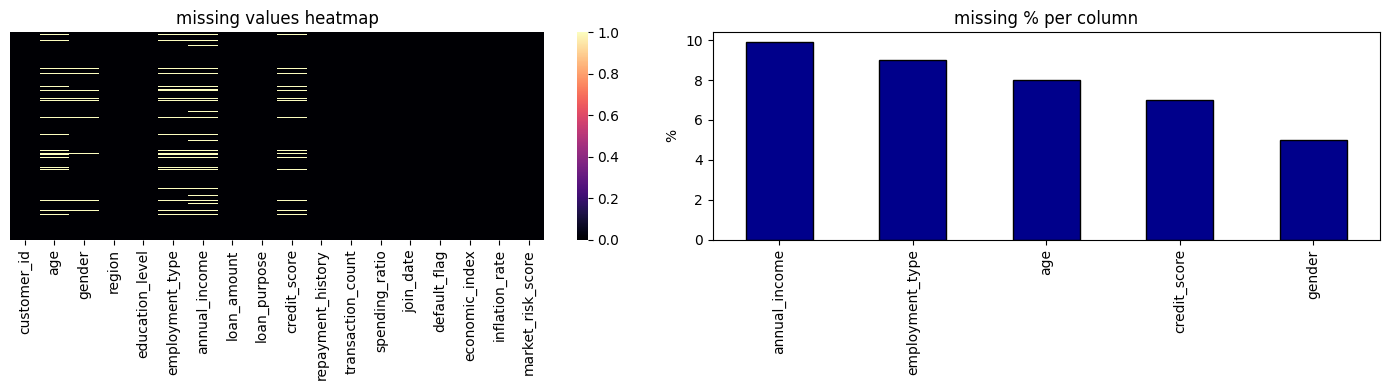

In [ ]:
# missing values overview
mv = df.isnull().sum()
mv_pct = (mv / len(df) * 100).round(2)
mv_df = pd.DataFrame({'count': mv, 'pct': mv_pct})
mv_df = mv_df[mv_df['count'] > 0].sort_values('count', ascending=False)
print(mv_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='magma', ax=axes[0])
axes[0].set_title('missing values heatmap')
mv_pct[mv_pct > 0].sort_values(ascending=False).plot(
    kind='bar', color='darkblue', edgecolor='black', ax=axes[1]
)
axes[1].set_title('missing % per column')
axes[1].set_ylabel('%')
plt.tight_layout()
plt.show()


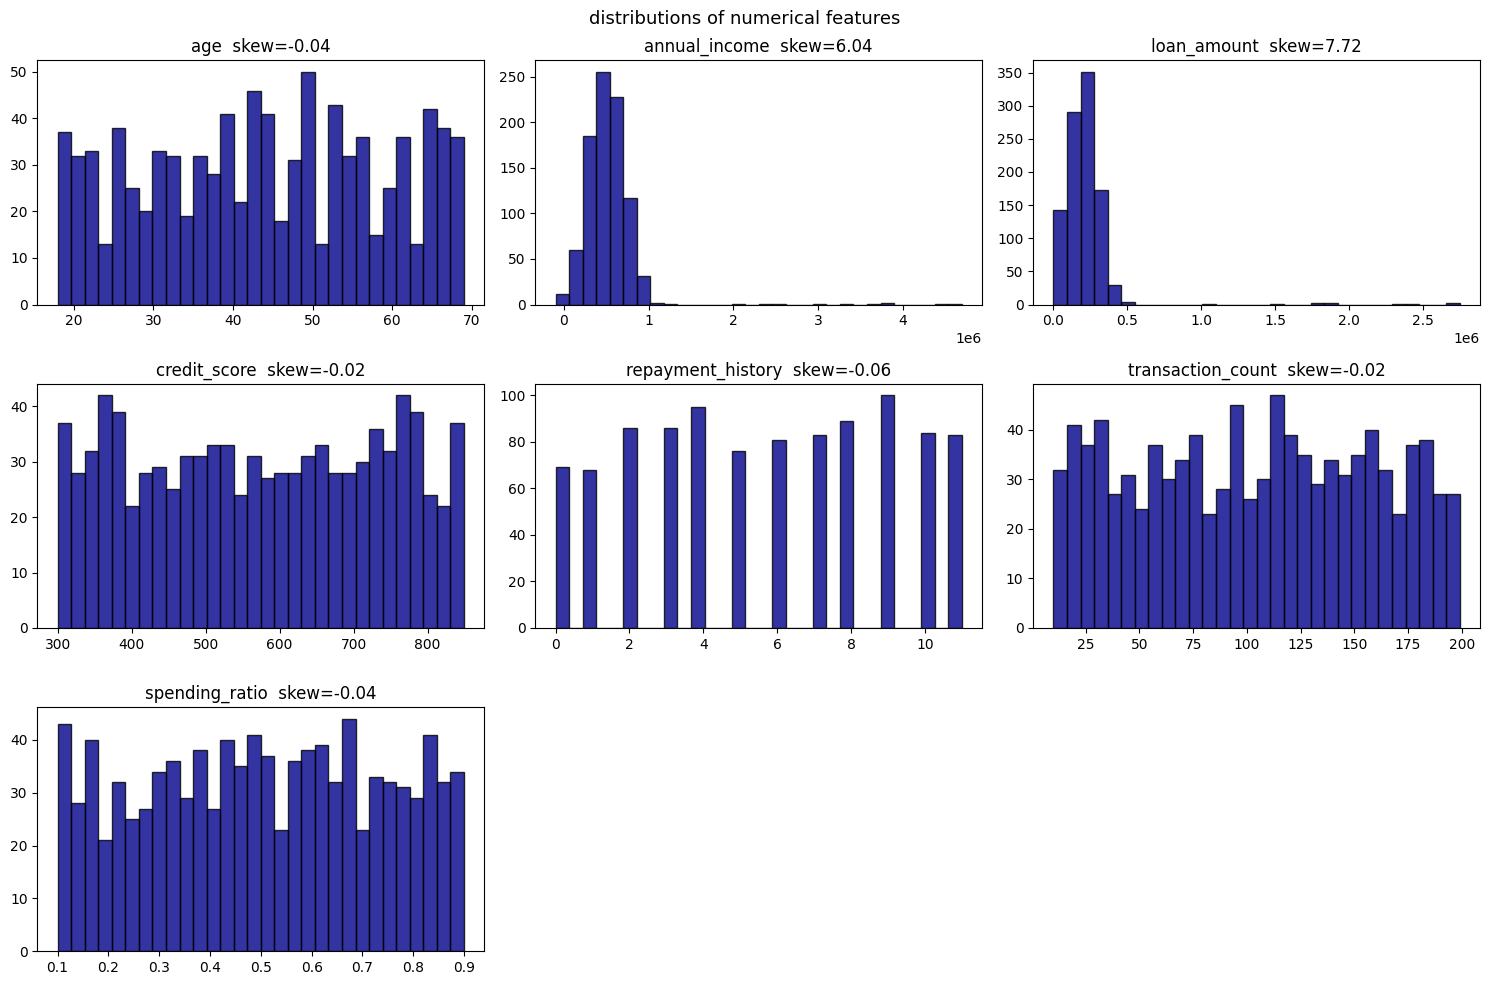

note: income and loan_amount are right-skewed, log transform will help later


In [ ]:
# distributions of numerical features
num_cols_eda = ['age','annual_income','loan_amount','credit_score',
               'repayment_history','transaction_count','spending_ratio']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    axes[i].hist(df[col].dropna(), bins=30, color='darkblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col + "  skew=" + str(round(df[col].skew(), 2)))

for j in range(len(num_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('distributions of numerical features', fontsize=13)
plt.tight_layout()
plt.show()
print("note: income and loan_amount are right-skewed, log transform will help later")


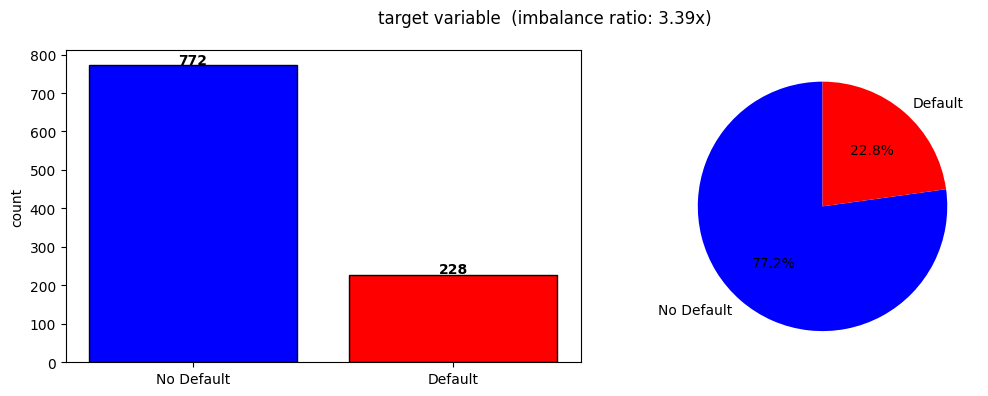

In [ ]:
# target variable distribution
counts = df['default_flag'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['blue','red']
labels = ['No Default', 'Default']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('count')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90)

ratio = round(counts.max() / counts.min(), 2)
plt.suptitle('target variable  (imbalance ratio: ' + str(ratio) + 'x)', fontsize=12)
plt.tight_layout()
plt.show()


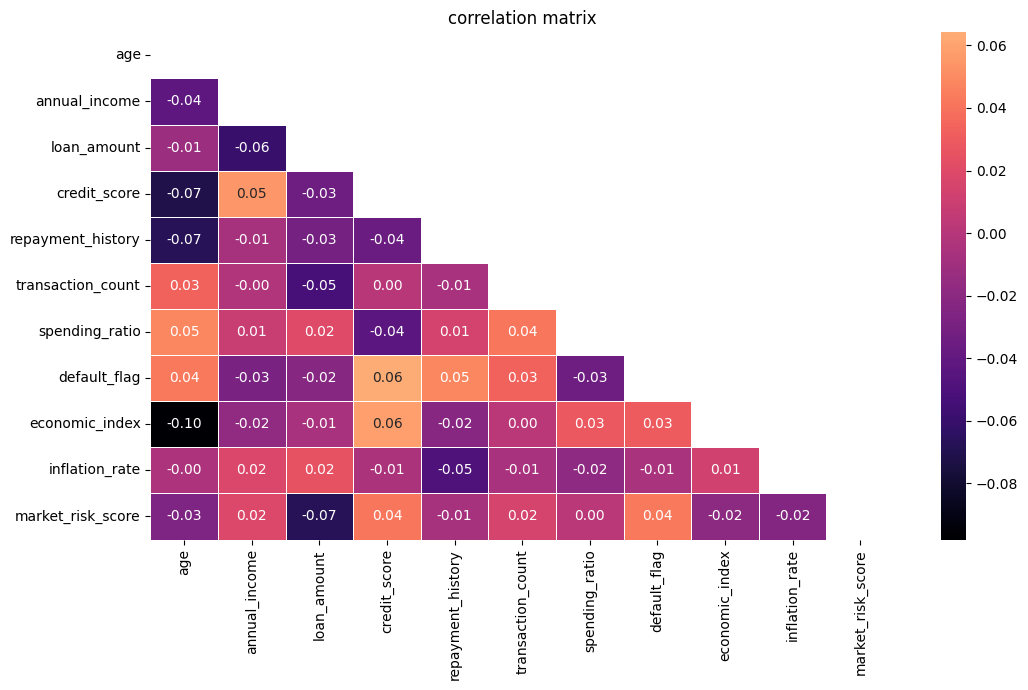

In [ ]:
# correlation matrix
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(11, 7))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='magma', center=0, linewidths=0.5)
plt.title('correlation matrix')
plt.tight_layout()
plt.show()


### 5. Pandas Profiling

In [ ]:
# holistic profiling report
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Credit Risk — Data Quality Report",
                            explorative=True, minimal=True)
    profile.to_file("data_quality_report.html")
    print("report saved: data_quality_report.html")
except ImportError:
    print("install ydata-profiling first:  pip install ydata-profiling")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 166.28it/s]

report saved: data_quality_report.html


In [27]:
# Open the generated EDA report in the default web browser
import webbrowser
webbrowser.open("data_quality_report.html")

True

### 6. Handling missing values

I will use multiple strategies:
- numerical: mean, median, KNN, MICE
- categorical: most frequent, random sample
- also try dropping rows and columns


In [28]:
# 6a — simple imputer numerical (mean and median)
df_imputed = df.copy()

print("missing before:")
print(df_imputed[['age','annual_income','credit_score']].isnull().sum().to_string())

mean_imp   = SimpleImputer(strategy="mean")
median_imp = SimpleImputer(strategy="median")

df_imputed[['age','annual_income','credit_score']] = mean_imp.fit_transform(
    df_imputed[['age','annual_income','credit_score']]
)
df_imputed[['loan_amount']] = median_imp.fit_transform(df_imputed[['loan_amount']])

print("missing after mean/median:")
print(df_imputed[['age','annual_income','credit_score','loan_amount']].isnull().sum().to_string())


missing before:
age              80
annual_income    99
credit_score     70
missing after mean/median:
age              0
annual_income    0
credit_score     0
loan_amount      0


In [29]:
# 6b — simple imputer categorical (most frequent)
cat_imp = SimpleImputer(strategy="most_frequent")

print("missing before:")
print(df_imputed[['employment_type','gender']].isnull().sum().to_string())

df_imputed[['employment_type','gender']] = cat_imp.fit_transform(
    df_imputed[['employment_type','gender']]
)

print("missing after most frequent:")
print(df_imputed[['employment_type','gender']].isnull().sum().to_string())


missing before:
employment_type    90
gender             50
missing after most frequent:
employment_type    0
gender             0


In [30]:
# 6c — missing indicator + random sample
df_rand = df.copy()

df_rand['income_was_missing'] = df_rand['annual_income'].isnull().astype(int)
df_rand['age_was_missing']    = df_rand['age'].isnull().astype(int)

print("indicators created — how many were missing:")
print(df_rand[['income_was_missing','age_was_missing']].sum().to_string())

for col in ['annual_income', 'age']:
    miss_idx    = df_rand[df_rand[col].isnull()].index
    fill_vals   = df_rand[col].dropna().sample(len(miss_idx), replace=True, random_state=0)
    df_rand.loc[miss_idx, col] = fill_vals.values

print("missing after random sample:")
print(df_rand[['annual_income','age']].isnull().sum().to_string())


indicators created — how many were missing:
income_was_missing    99
age_was_missing       80
missing after random sample:
annual_income    0
age              0


In [31]:
# 6d — KNN imputer
df_knn = df.copy()

print("missing before KNN:")
print(df_knn[['annual_income','credit_score','age']].isnull().sum().to_string())

knn_imp = KNNImputer(n_neighbors=5)
df_knn[['annual_income','credit_score','age']] = knn_imp.fit_transform(
    df_knn[['annual_income','credit_score','age']]
)

print("missing after KNN:")
print(df_knn[['annual_income','credit_score','age']].isnull().sum().to_string())


missing before KNN:
annual_income    99
credit_score     70
age              80
missing after KNN:
annual_income    0
credit_score     0
age              0


In [32]:
# 6e — MICE (iterative imputer)
df_mice = df.copy()

print("missing before MICE:")
print(df_mice[['annual_income','credit_score','age']].isnull().sum().to_string())

mice_imp = IterativeImputer(random_state=42, max_iter=10)
df_mice[['annual_income','credit_score','age']] = mice_imp.fit_transform(
    df_mice[['annual_income','credit_score','age']]
)

print("missing after MICE:")
print(df_mice[['annual_income','credit_score','age']].isnull().sum().to_string())


missing before MICE:
annual_income    99
credit_score     70
age              80
missing after MICE:
annual_income    0
credit_score     0
age              0


In [33]:
# 6f — complete case analysis (drop rows / columns)
df_drop_rows = df.dropna()
print("original rows    :", df.shape[0])
print("after dropna     :", df_drop_rows.shape[0])
print("rows removed     :", df.shape[0] - df_drop_rows.shape[0])

thresh       = int(0.70 * len(df))
df_drop_cols = df.dropna(axis=1, thresh=thresh)
print("after dropping cols with >30% missing:", df_drop_cols.shape)


original rows    : 1000
after dropna     : 900
rows removed     : 100
after dropping cols with >30% missing: (1000, 18)


In [34]:
# going forward I will use the KNN imputed version
df = df_knn.copy()
df[['employment_type','gender']] = cat_imp.fit_transform(df[['employment_type','gender']])

remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("no missing values left, ready to continue")
else:
    print(remaining.to_string())
print("shape:", df.shape)


no missing values left, ready to continue
shape: (1000, 18)


---
## Part D — Outlier Handling

### 7. Detecting and treating outliers

I will check annual_income, loan_amount and credit_score using four methods.


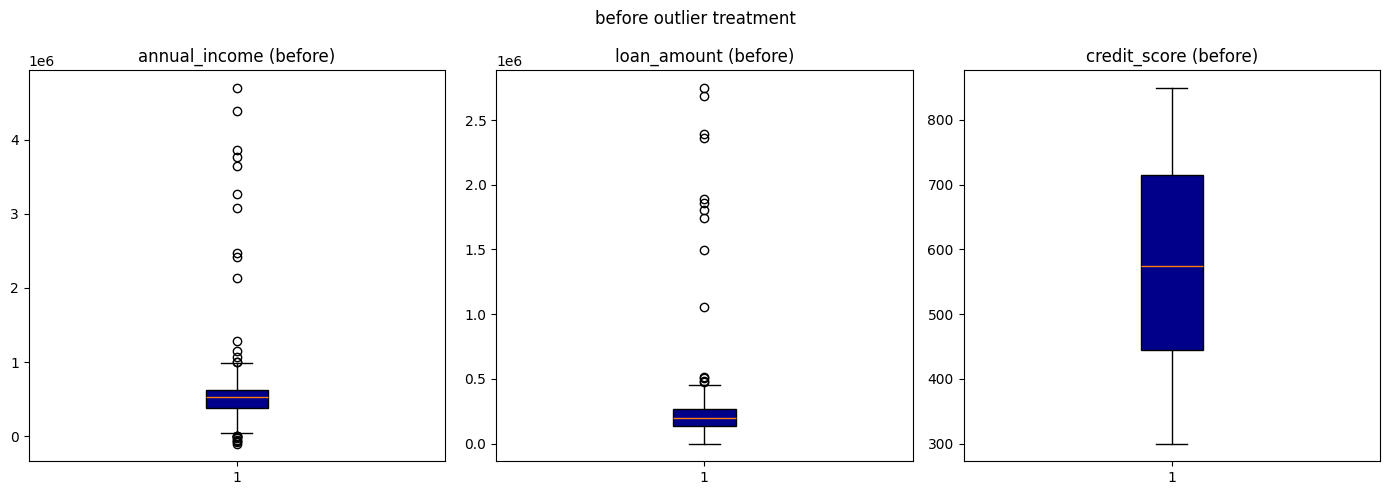

In [ ]:
# outlier detection with boxplots
num_cols = ['annual_income', 'loan_amount', 'credit_score']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='darkblue', color='black'))
    axes[i].set_title(col + " (before)")
plt.suptitle('before outlier treatment', fontsize=12)
plt.tight_layout()
plt.show()


In [37]:
# method 1 — Z-score
z      = np.abs(stats.zscore(df[num_cols]))
df_z   = df[(z < 3).all(axis=1)].copy()
print("Z-score: removed", df.shape[0] - df_z.shape[0], "rows out of", df.shape[0])


Z-score: removed 20 rows out of 1000


In [38]:
# method 2 — IQR
df_iqr = df.copy()
for col in num_cols:
    Q1  = df_iqr[col].quantile(0.25)
    Q3  = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    df_iqr = df_iqr[(df_iqr[col] >= Q1 - 1.5*IQR) & (df_iqr[col] <= Q3 + 1.5*IQR)]
print("IQR: removed", df.shape[0] - df_iqr.shape[0], "rows")


IQR: removed 38 rows


In [39]:
# method 3 — percentile clipping (1st to 99th)
df_pct = df.copy()
for col in num_cols:
    lo = df_pct[col].quantile(0.01)
    hi = df_pct[col].quantile(0.99)
    df_pct = df_pct[(df_pct[col] >= lo) & (df_pct[col] <= hi)]
print("Percentile: removed", df.shape[0] - df_pct.shape[0], "rows")


Percentile: removed 59 rows


In [40]:
# method 4 — winsorization (caps values instead of dropping)
df_win = df.copy()
for col in num_cols:
    df_win[col] = winsorize(df_win[col], limits=[0.05, 0.05])
print("Winsorization: shape unchanged", df_win.shape, " (values capped, no rows dropped)")
print("income max before:", round(df['annual_income'].max()))
print("income max after :", round(df_win['annual_income'].max()))


Winsorization: shape unchanged (1000, 18)  (values capped, no rows dropped)
income max before: 4694353
income max after : 840503


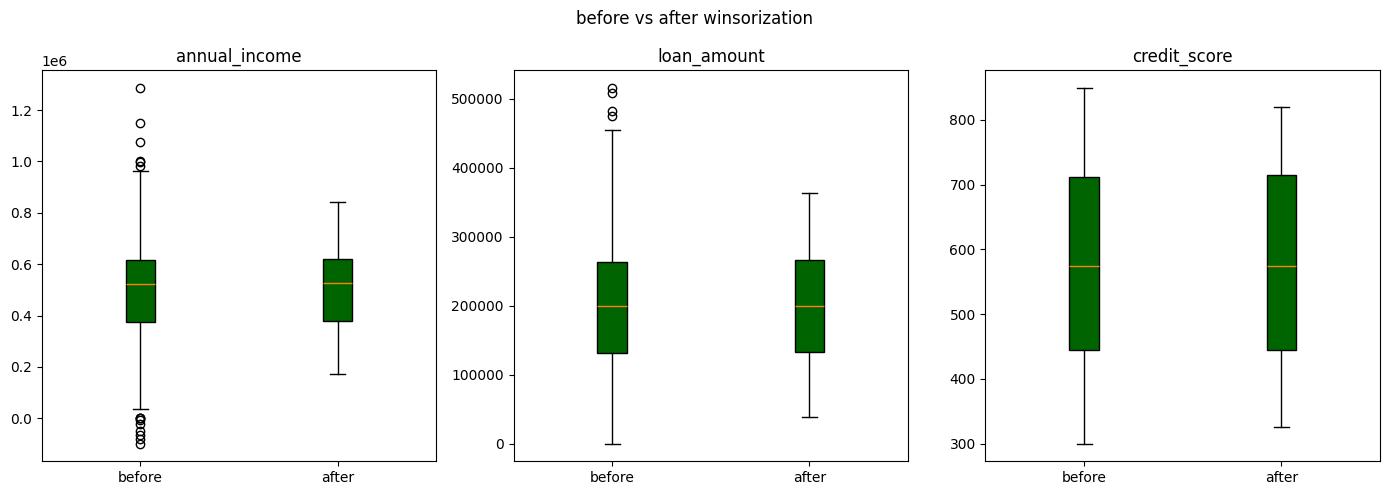

using z-score cleaned df: (980, 18)


In [42]:
# compare before vs after visually
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot([df[col].dropna(), df_win[col].dropna()],
                    labels=['before', 'after'],
                    patch_artist=True,
                    boxprops=dict(facecolor='darkgreen', color='black'))
    axes[i].set_title(col)
plt.suptitle('before vs after winsorization', fontsize=12)
plt.tight_layout()
plt.show()

# use z-score cleaned df going forward
df = df_z.copy()
print("using z-score cleaned df:", df.shape)


---
## Part E — Feature Engineering

### 8. Handling different variable types


In [ ]:
# final overview of the cleaned dataset
num_cols_all = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols_all = df.select_dtypes(include=['object']).columns.tolist()
date_cols    = df.select_dtypes(include=['datetime64']).columns.tolist()

print("numerical :", num_cols_all)
print("categorical:", cat_cols_all)
print("date cols  :", date_cols)

for col in cat_cols_all:
    print(col + ":", df[col].value_counts().to_dict())


numerical : ['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'default_flag', 'economic_index', 'inflation_rate', 'market_risk_score']
categorical: ['customer_id', 'gender', 'region', 'education_level', 'employment_type', 'loan_purpose', 'join_date']
date cols  : []
customer_id: {'CUST1000': 1, 'CUST0001': 1, 'CUST0002': 1, 'CUST0003': 1, 'CUST0984': 1, 'CUST0983': 1, 'CUST0982': 1, 'CUST0981': 1, 'CUST0980': 1, 'CUST0979': 1, 'CUST0978': 1, 'CUST0977': 1, 'CUST0976': 1, 'CUST0975': 1, 'CUST0974': 1, 'CUST0973': 1, 'CUST0972': 1, 'CUST0971': 1, 'CUST0970': 1, 'CUST0969': 1, 'CUST0038': 1, 'CUST0037': 1, 'CUST0036': 1, 'CUST0035': 1, 'CUST0034': 1, 'CUST0033': 1, 'CUST0032': 1, 'CUST0031': 1, 'CUST0030': 1, 'CUST0029': 1, 'CUST0027': 1, 'CUST0026': 1, 'CUST0025': 1, 'CUST0024': 1, 'CUST0023': 1, 'CUST0022': 1, 'CUST0055': 1, 'CUST0054': 1, 'CUST0053': 1, 'CUST0052': 1, 'CUST0051': 1, 'CUST0050': 1, 'CUST0049': 1, 'CUST004

   join_date  join_year  join_month  join_day  join_weekday  join_quarter  tenure_days
0 2018-01-01       2018           1         1             0             1         3044
1 2018-01-02       2018           1         2             1             1         3043
2 2018-01-03       2018           1         3             2             1         3042
3 2018-01-04       2018           1         4             3             1         3041
4 2018-01-05       2018           1         5             4             1         3040


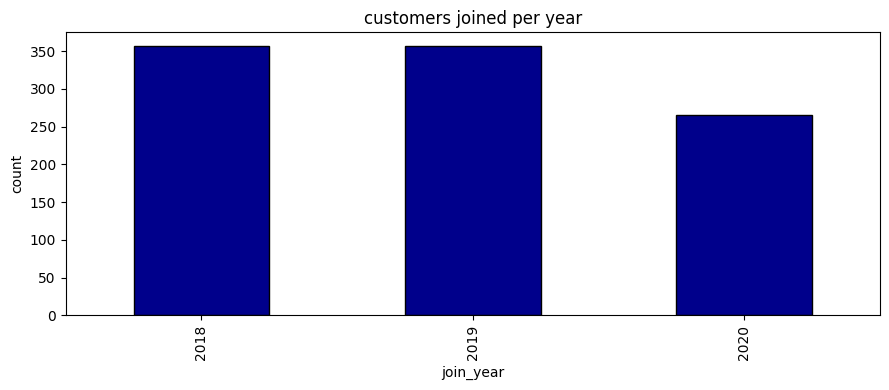

In [45]:
# date/time — extract useful components from join_date
df['join_date']            = pd.to_datetime(df['join_date'])
df['join_year']            = df['join_date'].dt.year
df['join_month']           = df['join_date'].dt.month
df['join_day']             = df['join_date'].dt.day
df['join_weekday']         = df['join_date'].dt.weekday
df['join_quarter']         = df['join_date'].dt.quarter
df['tenure_days']          = (pd.Timestamp.today() - df['join_date']).dt.days

print(df[['join_date','join_year','join_month','join_day',
          'join_weekday','join_quarter','tenure_days']].head(5).to_string())

plt.figure(figsize=(9, 4))
df.groupby('join_year')['customer_id'].count().plot(kind='bar', color='darkblue', edgecolor='black')
plt.title('customers joined per year')
plt.ylabel('count')
plt.tight_layout()
plt.show()


### 9. Encoding categorical variables

In [46]:
# ordinal encoding — education_level has a natural order
df_enc = df.copy()

edu_order = [['Primary','Secondary','Graduate','Post-Graduate']]
ord_enc   = OrdinalEncoder(categories=edu_order)
df_enc['education_encoded'] = ord_enc.fit_transform(df_enc[['education_level']])

print("ordinal encoding for education_level:")
tmp = df_enc[['education_level','education_encoded']].drop_duplicates().sort_values('education_encoded')
print(tmp.to_string())


ordinal encoding for education_level:
  education_level  education_encoded
2         Primary                0.0
0       Secondary                1.0
3        Graduate                2.0
8   Post-Graduate                3.0


In [47]:
# label encoding — gender
le = LabelEncoder()
df_enc['gender_encoded'] = le.fit_transform(df_enc['gender'].astype(str))

print("label encoding for gender:")
for cls, val in zip(le.classes_, range(len(le.classes_))):
    print(" ", cls, "->", val)


label encoding for gender:
  Female -> 0
  Male -> 1
  Other -> 2


In [48]:
# one-hot encoding — region and loan_purpose
df_enc = pd.get_dummies(df_enc, columns=['region','loan_purpose'], drop_first=False, dtype=int)

ohe_cols = [c for c in df_enc.columns if c.startswith('region_') or c.startswith('loan_purpose_')]
print("one-hot encoded columns:", ohe_cols)
print("shape after OHE:", df_enc.shape)


one-hot encoded columns: ['region_East', 'region_North', 'region_South', 'region_West', 'loan_purpose_Business', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other']
shape after OHE: (980, 33)


### 10. Encoding numerical features — binning, binarization

income bin counts:
income_bin_label
Low           93
Medium       604
High         271
Very High     12


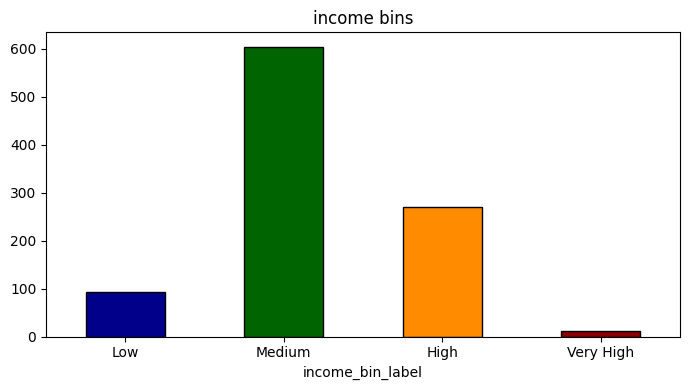

In [50]:
# equal width binning on annual_income
df_enc['income_bin_label'] = pd.cut(df_enc['annual_income'], bins=4,
                                    labels=['Low','Medium','High','Very High'])
df_enc['income_bin']       = pd.cut(df_enc['annual_income'], bins=4, labels=False)

print("income bin counts:")
print(df_enc['income_bin_label'].value_counts().sort_index().to_string())

plt.figure(figsize=(7, 4))
df_enc['income_bin_label'].value_counts().sort_index().plot(
    kind='bar', color=['darkblue','darkgreen','darkorange','darkred'], edgecolor='black'
)
plt.title('income bins')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [51]:
# binarization — flag credit score > 700
df_enc['credit_flag']    = (df_enc['credit_score'] > 700).astype(int)
df_enc['high_risk_flag'] = (df_enc['repayment_history'] > 6).astype(int)

print("credit_flag (1 = score > 700):")
print(df_enc['credit_flag'].value_counts().to_string())
print("high_risk_flag (1 = missed payments > 6):")
print(df_enc['high_risk_flag'].value_counts().to_string())


credit_flag (1 = score > 700):
credit_flag
0    720
1    260
high_risk_flag (1 = missed payments > 6):
high_risk_flag
0    546
1    434


In [52]:
# quantile binning — equal frequency bins
df_enc['income_qbin'] = pd.qcut(df_enc['annual_income'], q=4,
                                 labels=['Q1','Q2','Q3','Q4'])
print("quantile bins (equal frequency):")
print(df_enc['income_qbin'].value_counts().sort_index().to_string())


quantile bins (equal frequency):
income_qbin
Q1    245
Q2    245
Q3    245
Q4    245


In [53]:
# k-means binning on transaction_count
km    = KMeans(n_clusters=4, random_state=42, n_init=10)
df_enc['txn_cluster'] = km.fit_predict(df_enc[['transaction_count']])

print("k-means clusters for transaction_count:")
print(df_enc['txn_cluster'].value_counts().sort_index().to_string())
print("cluster centers:", sorted(km.cluster_centers_.flatten().astype(int).tolist()))


k-means clusters for transaction_count:
txn_cluster
0    254
1    226
2    258
3    242
cluster centers: [30, 76, 123, 172]


---
## Part F — Feature Scaling

### 11. Applying different scaling methods

Scaling is important because algorithms like KNN, SVM and neural nets are sensitive to the scale of features.

| Method | Output range | Good for |
|--------|-------------|---------|
| StandardScaler | mean=0, std=1 | SVM, PCA, most models |
| MinMaxScaler | 0 to 1 | neural networks |
| MaxAbsScaler | -1 to 1 | sparse data |
| RobustScaler | based on IQR | when outliers are present |
| Normalizer | unit norm per row | cosine similarity, NLP |


In [ ]:
# scaling — compare different scalers on annual_income
scale_cols = ['annual_income','loan_amount','credit_score','transaction_count','spending_ratio']
df_scale   = df_enc[scale_cols].copy()

scalers = {
    'Original'   : df_scale.copy(),
    'Standard'   : pd.DataFrame(StandardScaler().fit_transform(df_scale),  columns=scale_cols),
    'MinMax'     : pd.DataFrame(MinMaxScaler().fit_transform(df_scale),    columns=scale_cols),
    'MaxAbs'     : pd.DataFrame(MaxAbsScaler().fit_transform(df_scale),    columns=scale_cols),
    'Robust'     : pd.DataFrame(RobustScaler().fit_transform(df_scale),    columns=scale_cols),
    'Normalizer' : pd.DataFrame(Normalizer().fit_transform(df_scale),      columns=scale_cols),
}

print("annual_income stats after each scaler:")
for name, sdf in scalers.items():
    col = 'annual_income'
    print("  {:12s}  min={:.3f}  max={:.3f}  mean={:.3f}".format(
        name, sdf[col].min(), sdf[col].max(), sdf[col].mean()))


annual_income stats after each scaler:
  Original      min=-98227.194  max=1285247.541  mean=500976.710
  Standard      min=-3.076  max=4.026  mean=0.000
  MinMax        min=0.000  max=1.000  mean=0.433
  MaxAbs        min=-0.076  max=1.000  mean=0.390
  Robust        min=-2.569  max=3.166  mean=-0.085
  Normalizer    min=-0.375  max=1.000  mean=0.882


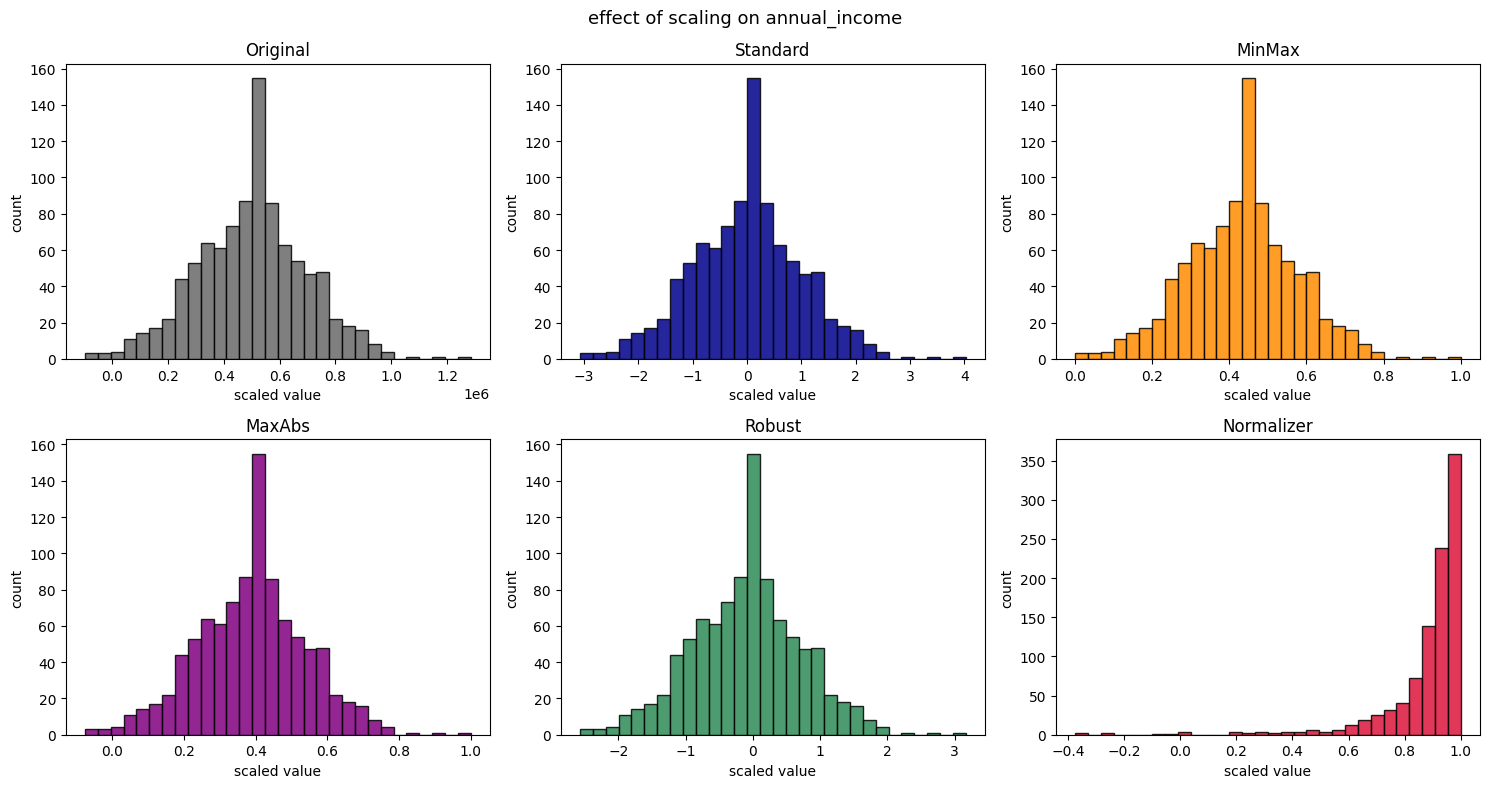

In [ ]:
# visualize the effect of scaling on annual_income
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes  = axes.flatten()
clrs  = ['dimgray','darkblue','darkorange','purple','seagreen','crimson']

for i, (name, sdf) in enumerate(scalers.items()):
    axes[i].hist(sdf['annual_income'], bins=30, color=clrs[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(name)
    axes[i].set_xlabel('scaled value')
    axes[i].set_ylabel('count')

plt.suptitle('effect of scaling on annual_income', fontsize=13)
plt.tight_layout()
plt.show()


---
## Part G — Feature Construction and Transformation

### 12. Applying mathematical transformations


In [ ]:
# feature engineering — log, sqrt, reciprocal transforms
df_feat = df_enc.copy()

# make sure columns are positive for log and sqrt
df_feat['annual_income'] = df_feat['annual_income'].clip(lower=1)
df_feat['loan_amount']   = df_feat['loan_amount'].clip(lower=1)
df_feat['spending_ratio'] = df_feat['spending_ratio'].clip(lower=0.001)

log_t  = FunctionTransformer(np.log1p)
sqrt_t = FunctionTransformer(np.sqrt)

df_feat['log_income']   = log_t.fit_transform(df_feat[['annual_income']])
df_feat['log_loan']     = log_t.fit_transform(df_feat[['loan_amount']])
df_feat['sqrt_spend']   = sqrt_t.fit_transform(df_feat[['spending_ratio']])
df_feat['recip_spend']  = 1 / (df_feat['spending_ratio'] + 1e-5)

print(df_feat[['log_income','log_loan','sqrt_spend','recip_spend']].describe().round(3).to_string())


       log_income  log_loan  sqrt_spend  recip_spend
count     980.000   980.000     980.000      980.000
mean       12.952    11.998       0.686        2.757
std         1.112     0.811       0.175        1.954
min         0.693     6.104       0.316        1.112
25%        12.838    11.791       0.557        1.454
50%        13.164    12.203       0.708        1.997
75%        13.333    12.483       0.829        3.224
max        14.066    13.152       0.948        9.984


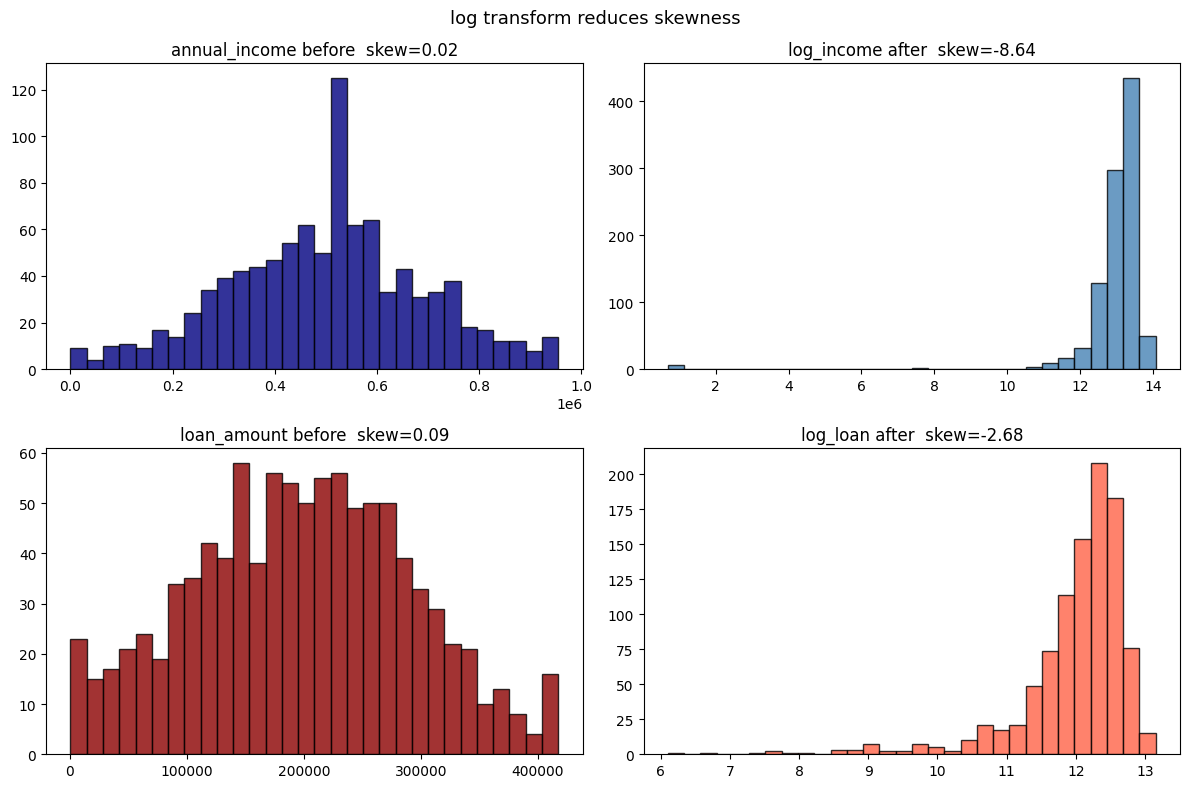

In [60]:
# before vs after log transform
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

income_clip = df_feat['annual_income'].clip(upper=df_feat['annual_income'].quantile(0.99))
axes[0,0].hist(income_clip, bins=30, color='navy', edgecolor='black', alpha=0.8)
axes[0,0].set_title("annual_income before  skew=" + str(round(df_feat['annual_income'].skew(), 2)))

axes[0,1].hist(df_feat['log_income'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0,1].set_title("log_income after  skew=" + str(round(df_feat['log_income'].skew(), 2)))

loan_clip = df_feat['loan_amount'].clip(upper=df_feat['loan_amount'].quantile(0.99))
axes[1,0].hist(loan_clip, bins=30, color='darkred', edgecolor='black', alpha=0.8)
axes[1,0].set_title("loan_amount before  skew=" + str(round(df_feat['loan_amount'].skew(), 2)))

axes[1,1].hist(df_feat['log_loan'], bins=30, color='tomato', edgecolor='black', alpha=0.8)
axes[1,1].set_title("log_loan after  skew=" + str(round(df_feat['log_loan'].skew(), 2)))

plt.suptitle('log transform reduces skewness', fontsize=13)
plt.tight_layout()
plt.show()


In [61]:
# box-cox and yeo-johnson power transforms
df_power = df_feat.copy()

pt_yj = PowerTransformer(method='yeo-johnson')
df_power['yj_income'] = pt_yj.fit_transform(df_power[['annual_income']])
df_power['yj_loan']   = pt_yj.fit_transform(df_power[['loan_amount']])

pt_bc = PowerTransformer(method='box-cox')
pos_inc = df_power['annual_income'].clip(lower=0.01)
df_power['bc_income'] = pt_bc.fit_transform(pos_inc.values.reshape(-1, 1))

print("skewness comparison for annual_income:")
print("  original     :", round(df_power['annual_income'].skew(), 3))
print("  yeo-johnson  :", round(df_power['yj_income'].skew(), 3))
print("  box-cox      :", round(df_power['bc_income'].skew(), 3))
print("yeo-johnson works on all values, box-cox needs strictly positive values")


skewness comparison for annual_income:
  original     : 0.015
  yeo-johnson  : -0.225
  box-cox      : -0.239
yeo-johnson works on all values, box-cox needs strictly positive values


In [62]:
# column transformer — applying different transforms to different columns in one step
num_ct = ['annual_income','loan_amount','credit_score']
cat_ct = ['education_level']

preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_ct),
    ('encode', OrdinalEncoder(
        categories=[['Primary','Secondary','Graduate','Post-Graduate']]
    ), cat_ct),
], remainder='drop')

out = preprocessor.fit_transform(df[num_ct + cat_ct].copy())
print("column transformer output shape:", out.shape)
print("standard scaling applied to numericals, ordinal encoding to education_level")


column transformer output shape: (980, 4)
standard scaling applied to numericals, ordinal encoding to education_level


### 13. Building new features

In [ ]:
# feature engineering — creating new features from existing ones
df_final = df_feat.copy()

df_final['debt_to_income']    = df_final['loan_amount'] / df_final['annual_income'].clip(lower=1)
df_final['avg_monthly_txn']   = df_final['transaction_count'] / 6
df_final['spend_to_income']   = df_final['spending_ratio'] / df_final['annual_income'].clip(lower=1)
df_final['loan_to_credit']    = df_final['loan_amount'] / df_final['credit_score'].clip(lower=1)
df_final['risk_score']        = (
    df_final['repayment_history'] * 0.4 +
    df_final['debt_to_income'].clip(upper=5) * 0.3 +
    (1 - df_final['credit_score'] / 850) * 0.3
)

new_feats = ['debt_to_income','avg_monthly_txn','spend_to_income','loan_to_credit','risk_score']
print(df_final[new_feats].describe().round(4).to_string())


       debt_to_income  avg_monthly_txn  spend_to_income  loan_to_credit  risk_score
count        980.0000         980.0000         980.0000        980.0000    980.0000
mean        1457.9651          17.2259           0.0036        377.3807      2.5434
std        18741.3965           9.0442           0.0468        225.3986      1.3712
min            0.0011           1.6667           0.0000          1.1758      0.0288
25%            0.2444           9.4583           0.0000        220.0741      1.3970
50%            0.3920          17.5000           0.0000        345.6226      2.5821
75%            0.5841          25.0000           0.0000        492.4411      3.7478
max       284688.2104          33.1667           0.7527       1281.6062      5.9960


---
## Part H — Final Deliverable

### 14. Exporting the cleaned and processed dataset


In [ ]:
# final dataset export — only numerical features for modeling, excluding date and binning labels
exclude = ['join_date','income_bin_label','income_qbin']
final_cols = [c for c in df_final.select_dtypes(include='number').columns
              if c not in exclude]

df_export = df_final[final_cols].copy()
df_export.to_csv("final_cleaned_dataset.csv", index=False)

print("exported: final_cleaned_dataset.csv")
print("shape:", df_export.shape)


exported: final_cleaned_dataset.csv
shape: (980, 41)


In [ ]:
# sanity check by loading the exported dataset and verifying key properties
df_check = pd.read_csv("final_cleaned_dataset.csv")

print("shape        :", df_check.shape)
print("missing vals :", df_check.isnull().sum().sum())
print("dtypes       :", df_check.dtypes.value_counts().to_dict())
print()
print(df_check.head(3).to_string())


shape        : (980, 41)
missing vals : 0
dtypes       : {dtype('int64'): 23, dtype('float64'): 18}

    age  annual_income    loan_amount  credit_score  repayment_history  transaction_count  spending_ratio  default_flag  economic_index  inflation_rate  market_risk_score  join_year  join_month  join_day  join_weekday  join_quarter  tenure_days  education_encoded  gender_encoded  region_East  region_North  region_South  region_West  loan_purpose_Business  loan_purpose_Car  loan_purpose_Education  loan_purpose_Home  loan_purpose_Other  income_bin  credit_flag  high_risk_flag  txn_cluster  log_income   log_loan  sqrt_spend  recip_spend  debt_to_income  avg_monthly_txn  spend_to_income  loan_to_credit  risk_score
0  56.0  312698.725042  295001.582867         616.0                  5                 11        0.748413             0          106.89            6.73              0.250       2018           1         1             0             1         3044                1.0               0  

In [74]:
# final overview of the cleaned dataset
print("=" * 55)
print("    Preprocessing Summary")
print("=" * 55)

rows = [
    ("Data sources",       "CSV, JSON, SQL, dummy API  (4 sources)"),
    ("Final shape",        str(df_check.shape[0]) + " rows  x  " + str(df_check.shape[1]) + " cols"),
    ("Missing values",     str(df_check.isnull().sum().sum())),
    ("Imputation",         "mean/median, most-frequent, random sample, KNN, MICE, dropna"),
    ("Outlier methods",    "Z-score, IQR, percentile, winsorization"),
    ("Encoding",           "ordinal, label, one-hot, binning, binarization, quantile, k-means"),
    ("Scaling",            "standard, minmax, maxabs, robust, normalizer"),
    ("Transforms",         "log, sqrt, reciprocal, yeo-johnson, box-cox"),
    ("New features",       "debt_to_income, avg_monthly_txn, spend_to_income, loan_to_credit, risk_score"),
    ("Target",             "default_flag  (0=no default  1=default)"),
]

for k, v in rows:
    print("  {:22s}: {}".format(k, v))

print("=" * 55)
print("Dataset is ready for ML Modeling")


    Preprocessing Summary
  Data sources          : CSV, JSON, SQL, dummy API  (4 sources)
  Final shape           : 980 rows  x  41 cols
  Missing values        : 0
  Imputation            : mean/median, most-frequent, random sample, KNN, MICE, dropna
  Outlier methods       : Z-score, IQR, percentile, winsorization
  Encoding              : ordinal, label, one-hot, binning, binarization, quantile, k-means
  Scaling               : standard, minmax, maxabs, robust, normalizer
  Transforms            : log, sqrt, reciprocal, yeo-johnson, box-cox
  New features          : debt_to_income, avg_monthly_txn, spend_to_income, loan_to_credit, risk_score
  Target                : default_flag  (0=no default  1=default)
Dataset is ready for ML Modeling


---
## Done

Everything covered in this project:

| Part | What I did |
|------|-----------|
| A | explained data analysis, DS project planning, ML problem framing, tensors with numpy |
| B | loaded data from CSV, JSON, SQL and dummy API, merged into one master df |
| C | explored with info/describe, plotted distributions and correlations, handled missing values 6 ways |
| D | detected and removed outliers using Z-score, IQR, percentile and winsorization |
| E | handled mixed variable types, extracted datetime features, applied all encoding methods |
| F | applied 5 different scaling methods with visual comparison |
| G | applied log, sqrt, reciprocal, box-cox, yeo-johnson transforms, used column transformer, built new features |
| H | exported final clean dataset and printed summary |
